### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("pima-indians-diabetes.csv")

# Select two features
X_train = data[['glucose', 'bmi']].values
y_train = data['label'].values

# Scale the two features for stable gradient descent
X_train[:, 0] = X_train[:, 0] / 100
X_train[:, 1] = X_train[:, 1] / 50

m, n = X_train.shape

In [3]:
print(m)
print(n)

768
2


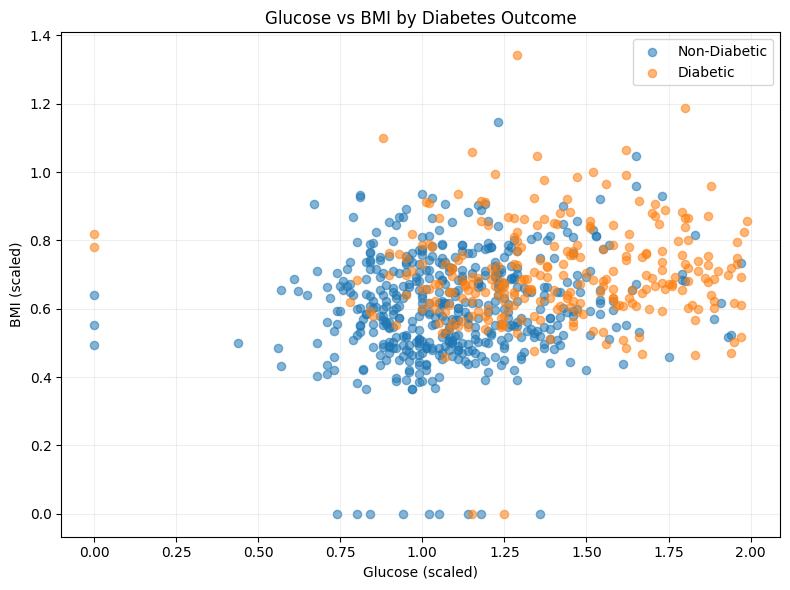

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color='tab:blue',
    label='Non-Diabetic',
    s=35,
    alpha=0.55
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color='tab:orange',
    label='Diabetic',
    s=35,
    alpha=0.55
)

plt.xlabel('Glucose (scaled)')
plt.ylabel('BMI (scaled)')
plt.title('Glucose vs BMI by Diabetes Outcome')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
def cost_function(X, y, w, b):
    cost_sum = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        g = np.clip(g, 1e-15, 1 - 1e-15)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1/m) * cost_sum

In [7]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])

        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i, j]

    grad_b = (1/m) * grad_b
    grad_w = (1/m) * grad_w

    return grad_b, grad_w

In [8]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0

    for i in range(iterations):

        grad_b, grad_w = gradient_function(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b):.4f}")

    return w, b

In [9]:
def predict(X, w, b):
    preds = np.zeros(len(X))

    for i in range(len(X)):

        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0

    return preds

In [10]:
learning_rate = 0.1
iterations = 10000

final_w, final_b = gradient_descent(
    X_train,
    y_train,
    learning_rate,
    iterations
)

predictions = predict(X_train, final_w, final_b)

accuracy = np.mean(predictions == y_train) * 100

print(f"Training Accuracy: {accuracy:.2f}%") 

Iteration 0: Cost 0.6892
Iteration 1000: Cost 0.5563
Iteration 2000: Cost 0.5283
Iteration 3000: Cost 0.5169
Iteration 4000: Cost 0.5111
Iteration 5000: Cost 0.5078
Iteration 6000: Cost 0.5058
Iteration 7000: Cost 0.5046
Iteration 8000: Cost 0.5038
Iteration 9000: Cost 0.5033
Training Accuracy: 76.56%


In [11]:
m = -final_w[0] / final_w[1]

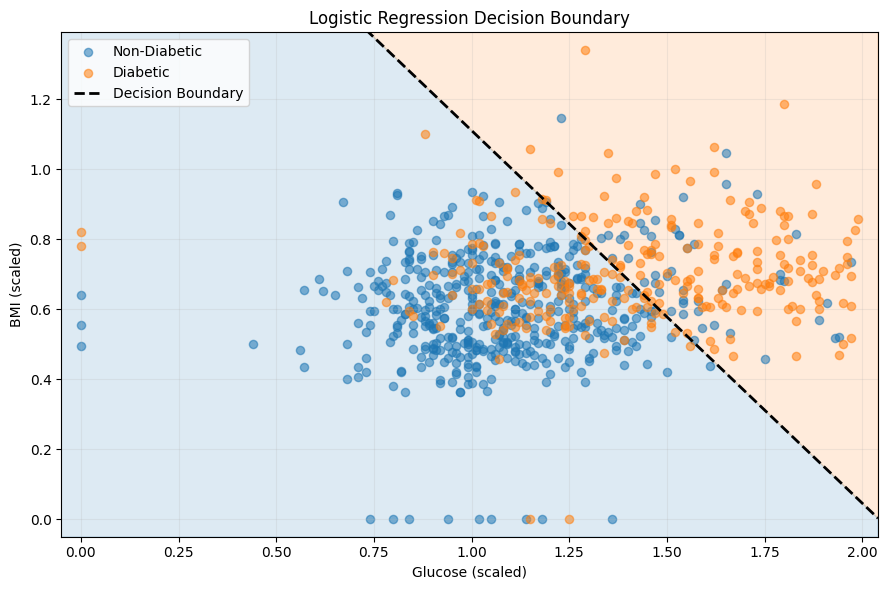

In [12]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin = X_train[:, 0].min() - 0.05
xmax = X_train[:, 0].max() + 0.05

ymin = X_train[:, 1].min() - 0.05
ymax = X_train[:, 1].max() + 0.05

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.figure(figsize=(9, 6))

# Decision regions
plt.fill_between(
    xd, yd, ymin,
    color='tab:blue',
    alpha=0.15
)

plt.fill_between(
    xd, yd, ymax,
    color='tab:orange',
    alpha=0.15
)

# Data points
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color='tab:blue',
    label='Non-Diabetic',
    s=35,
    alpha=0.55
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color='tab:orange',
    label='Diabetic',
    s=35,
    alpha=0.55
)

# Decision boundary
plt.plot(
    xd,
    yd,
    'k--',
    linewidth=2,
    label='Decision Boundary'
)

plt.xlabel('Glucose (scaled)')
plt.ylabel('BMI (scaled)')
plt.title('Logistic Regression Decision Boundary')

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()